
#Detecção de Anomalias em Transações em Python

#### Exemplo prático de um projeto desenvolvido para busca de possíveis fraudes financeiras que podem ocorrer.  

In [2]:
import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Problema de classificação desbalanceada
Fraudes são raras -> modelo pode ignorar a classe 1.

In [5]:
df["Class"].value_counts(normalize=True) # mostra a porcentagem de fraudes

,proportion
Class,
0,0.998273
1,0.001727


#Feature Engineering
Criamos variáveis que ajudam o modelo.



In [11]:
import numpy as np

df["Amount_log"] = np.log1p(df["Amount"]) # Reduz a diferença - Deixa a distribuição mais equilibrada


In [12]:
from sklearn.preprocessing import StandardScaler #Ferramenta que transforma os dados para média igual a zero e desvio padraão igual a 1.

scaler = StandardScaler() #Deixa em escala comum

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])

In [13]:
from sklearn.model_selection import train_test_split #

x = df.drop("Class", axis=1) #X variáveis de entradas - Caracteristicas
y = df["Class"]              #Y representa o que queremos ver

X_train, X_test, y_train, y_test = train_test_split(
    x, y, stratify=y, test_size=0.3, random_state=42
) #Divide dados em conjunto de treino e teste (Treino ensina (≠) Teste para avaliar o modelo depois)
   # test_size=0.3: 30% do dados é para teste / 70% é para ser treinado
   #random_state=42: Garantir que a divisão seja a mesma
   #stratify=y: Garante a proporção fraude e não fraude seja mantida


# Logistic Regression

In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000) #Mil interações, numero de interações

model.fit(X_train, y_train) # Aprende padrões a partir dos dados de treino

y_pred = model.predict(X_test) #Faz previsões nos dados de teste que nunca viu.

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.66      0.73       148

    accuracy                           1.00     85443
   macro avg       0.92      0.83      0.87     85443
weighted avg       1.00      1.00      1.00     85443



Accuracy pode ser alta mesmo sem detectar fraudes

por isso usamos:

*   recall (mais importante)
*   precision
* F1-score





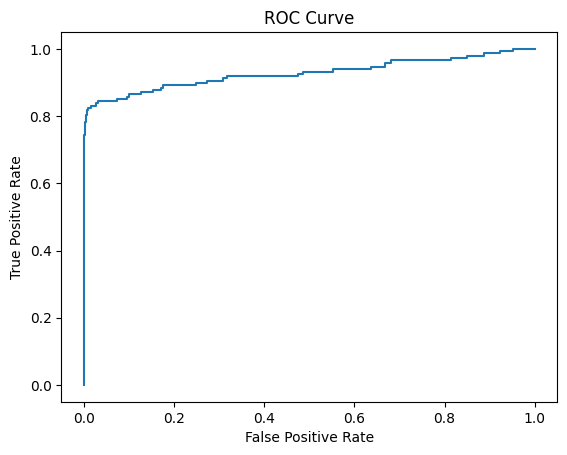

AUC: 0.9272042339543365


In [16]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs) #Metrica de desempenho do modelo

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate") #Taxas falsas positivas
plt.ylabel("True Positive Rate") #Fraudes realmente que conseguiu identificar
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

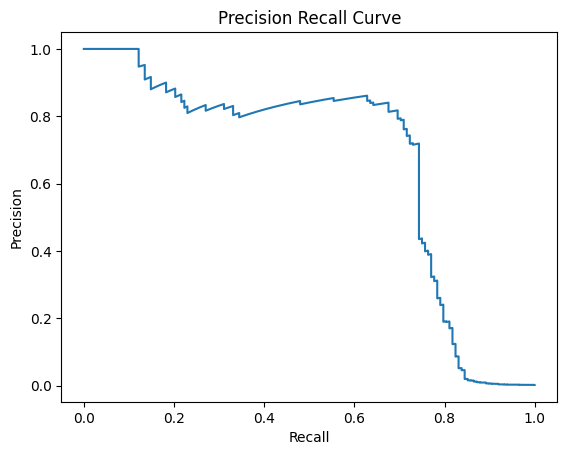

In [17]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision Recall Curve")
plt.xlabel("Recall") #Quantas fraudes consegue identificar
plt.ylabel("Precision") #Entre as transações classificadas como fraudes, quantas realmente são fraudes.
plt.show()


#Balanceamento de Dados

In [20]:
# Undersampling -  Aprende melhor a identificador fraudes, mas pode perder qualidade de dados. Reduzir a classe majoritária.

fraudes = df[df["Class"] == 1]
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)

df_under = pd.concat([fraudes, normais])

In [21]:
# Oversampling - Cria novos dados, baseados nas existentes. Não perde dados e aumenta a representação da classe fraude, mas cria dados artificias. Vai aumentar a classe minonitária.

from imblearn.over_sampling import SMOTE

smote = SMOTE()

X_res, y_res = smote.fit_resample(X_train, y_train)

In [22]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50, #Escolhando 50 arvores
    max_depth=10,    #Limitando a profundidade das arvores
    class_weight="balanced", #Ajusta automaticamente o peso das classes
    n_jobs=1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.84      0.76      0.79       148

    accuracy                           1.00     85443
   macro avg       0.92      0.88      0.90     85443
weighted avg       1.00      1.00      1.00     85443



In [25]:
#Pipeline - Serve para organizar o fluxo de processamento


from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()), #Passam pela padronização depois pelo o modelo
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

x_pred = pipeline.predict(X_test)

In [26]:
threshoud = 0.3 # Probabilidade de fraudes

y_pred_custom = (y_probs > threshoud).astype(int)

print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.79      0.71      0.75       148

    accuracy                           1.00     85443
   macro avg       0.89      0.85      0.87     85443
weighted avg       1.00      1.00      1.00     85443



# Modelo Avançado - XGBoost
XGBoost é um dos algoritmos mais usados em competições e mercado.

Ele é mais poderoso que o Random Forest para muitos problemas.

Boostin é uma aprendizado sequencial de varios modelos de arvores treinados em sequencia, na qual cada um corrige o outro.

In [27]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10, #ajuda com desbalanceamento
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [28]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.94      0.78      0.85       148

    accuracy                           1.00     85443
   macro avg       0.97      0.89      0.93     85443
weighted avg       1.00      1.00      1.00     85443



# Importância das variáveis
ajuda a entender quais variaveis influenciam mais o modelo.

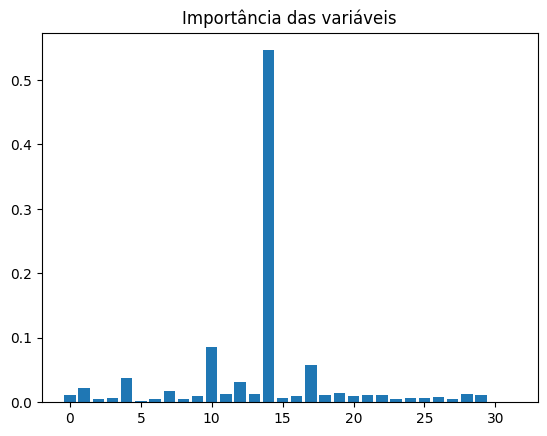

In [29]:

import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das variáveis")
plt.show()

#Ajuste de hiperparâmetros
Testamos várias combinações para melhorar o modelo.

In [30]:
from sklearn.model_selection import  GridSearchCV # Técnica testa automaticamente varias combinações de paramentros para achar a melhor.

param_grid = { #Conjunto de combinações que quer testar
    "max_depth" : [3, 5],
    "n_estimators" : [50, 100]
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"),
    param_grid,
    scoring="recall", #identifica qual o melhor
    cv=3
)

grid.fit(X_train, y_train)

print("Melhor modelo:", grid.best_params_)

Melhor modelo: {'max_depth': 5, 'n_estimators': 100}


# Explicabilidade (SHAP)
SHAP mostra como cada variável influencia a decisão do modelo

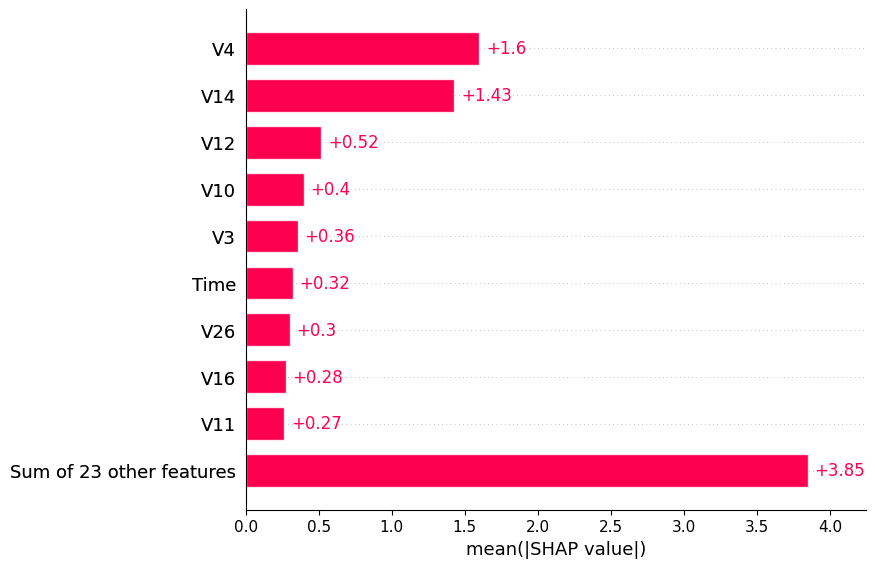

In [31]:
import shap #Técnica que explica como cada variavel contribuí para a decisão do modelo.

explainer = shap.Explainer(xgb)
shap_values = explainer(X_test[:100])

shap.plots.bar(shap_values)